In [1]:
import pandas as pd
import numpy as np
import time
import pickle
import warnings
warnings.filterwarnings('ignore')
import os

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# PSO
import pyswarms as ps

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
# ========================================
# CONFIGURATION
# ========================================

INPUT_FILE = "archive/full_df_binary_labels.csv"
BASE_MODEL_DIR = "trained_models/ml_optimized/pso/"  # dossier pour PSO
TEST_SIZE = 0.2
RANDOM_STATE = 42
SAVE_MODELS = True

# ========================================
# PSO CONFIGURATION
# ========================================
PSO_PARTICLES = 20      # Nombre de particules
PSO_ITERATIONS = 20     # Nombre d'itérations
PSO_SAMPLE_SIZE = 50000 # Taille échantillon si dataset énorme pour PSO

print(f"🎯 PSO Configuration: {PSO_PARTICLES} particles, {PSO_ITERATIONS} iterations")
print(f"📊 PSO Sample Size (max rows for optimization): {PSO_SAMPLE_SIZE:,}")

# ========================================
# PER-MODEL DATASET SIZE CONTROL
# ========================================

MODEL_SAMPLE_SIZES = {
    'Random Forest': None,        # Fast - use full dataset
    'Decision Tree': None,        # Fast - use full dataset
    'XGBoost': None,              # Fast - use full dataset ⭐ BEST MODEL
    'KNN': 50000,                 # SLOW - use only 50k rows
    'SVM': 100000,                # VERY SLOW - use only 100k rows
    'Naive Bayes': None           # Fast - use full dataset
}

print("\n📊 Per-Model Sample Sizes:")
for model, size in MODEL_SAMPLE_SIZES.items():
    size_str = 'Full dataset' if size is None else f'{size:,} rows'
    marker = ' ⭐' if model == 'XGBoost' else ''
    print(f"   {model}: {size_str}{marker}")

# Create base directory
os.makedirs(BASE_MODEL_DIR, exist_ok=True)
print(f"\n✅ Base model directory: {BASE_MODEL_DIR}")
print(f"\n🎯 Optimization: PSO (Particle Swarm Optimization)")


🎯 PSO Configuration: 20 particles, 20 iterations
📊 PSO Sample Size (max rows for optimization): 50,000

📊 Per-Model Sample Sizes:
   Random Forest: Full dataset
   Decision Tree: Full dataset
   XGBoost: Full dataset ⭐
   KNN: 50,000 rows
   SVM: 100,000 rows
   Naive Bayes: Full dataset

✅ Base model directory: trained_models/ml_optimized/pso/

🎯 Optimization: PSO (Particle Swarm Optimization)


In [3]:
# ========================================
# LOAD DATASET (Memory-Efficient)
# ========================================

CHUNK_SIZE = 100000
MAX_ROWS = None  # None = load all data, ou mettre une limite pour PSO

chunks = []
total_rows = 0

print("⏳ Reading data...")
for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    if MAX_ROWS and total_rows >= MAX_ROWS:
        break
    
    if MAX_ROWS and total_rows + len(chunk) > MAX_ROWS:
        chunk = chunk.head(MAX_ROWS - total_rows)
    
    chunks.append(chunk)
    total_rows += len(chunk)
    
    if (i + 1) % 5 == 0:
        print(f"   Loaded chunk {i+1}: {total_rows:,} rows total")

print(f"\n✅ Loaded {len(chunks)} chunks")
print(f"✅ Total rows: {total_rows:,}")

print("\n🔗 Combining chunks...")
df_full = pd.concat(chunks, ignore_index=True)
del chunks

print(f"✅ Dataset shape: {df_full.shape}")
print(f"✅ Columns: {len(df_full.columns)}")


⏳ Reading data...
   Loaded chunk 5: 500,000 rows total
   Loaded chunk 10: 1,000,000 rows total
   Loaded chunk 15: 1,500,000 rows total
   Loaded chunk 20: 2,000,000 rows total
   Loaded chunk 25: 2,500,000 rows total
   Loaded chunk 30: 3,000,000 rows total
   Loaded chunk 35: 3,500,000 rows total
   Loaded chunk 40: 4,000,000 rows total
   Loaded chunk 45: 4,500,000 rows total
   Loaded chunk 50: 5,000,000 rows total
   Loaded chunk 55: 5,500,000 rows total
   Loaded chunk 60: 6,000,000 rows total
   Loaded chunk 65: 6,500,000 rows total
   Loaded chunk 70: 7,000,000 rows total
   Loaded chunk 75: 7,500,000 rows total
   Loaded chunk 80: 8,000,000 rows total
   Loaded chunk 85: 8,500,000 rows total
   Loaded chunk 90: 9,000,000 rows total
   Loaded chunk 95: 9,500,000 rows total
   Loaded chunk 100: 10,000,000 rows total
   Loaded chunk 105: 10,500,000 rows total
   Loaded chunk 110: 11,000,000 rows total
   Loaded chunk 115: 11,500,000 rows total
   Loaded chunk 120: 12,000,000 ro

In [4]:
# ========================================
# SEPARATE FEATURES AND TARGET
# ========================================

label_columns = ['Label', 'Label_Binary']
existing_labels = [col for col in label_columns if col in df_full.columns]

# Features et target
X_full = df_full.drop(columns=existing_labels)
y_full = df_full['Label_Binary']

print(f"✅ Features (X): {X_full.shape}")
print(f"✅ Target (y): {y_full.shape}")
print(f"\n📊 Total features: {X_full.shape[1]}")
print(f"🎯 Note: PCA not applied, all features retained for PSO optimization")


✅ Features (X): (16232943, 57)
✅ Target (y): (16232943,)

📊 Total features: 57
🎯 Note: PCA not applied, all features retained for PSO optimization


In [5]:
# ========================================
# DEFINE MODELS
# ========================================

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=1
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ),
    'SVM': SVC(
        kernel='rbf',
        random_state=RANDOM_STATE,
        verbose=True
    ),
    'Naive Bayes': GaussianNB()
}

print(f"✅ Defined {len(models)} models")


✅ Defined 6 models


In [6]:
# ========================================
# HELPER FUNCTIONS
# ========================================

from sklearn.metrics import confusion_matrix

def calculate_far(y_true, y_pred):
    """
    Calculate False Alert Rate (FAR)
    FAR = FP / (FP + TN)
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    return far


def get_model_data(X_full, y_full, model_name, sample_size, test_size, random_state):
    """
    Get train/test split with optional sampling.
    Works for PSO or normal training.
    """
    if sample_size is None:
        X = X_full
        y = y_full
        print(f"📊 Using FULL dataset: {len(X):,} rows")
    else:
        if sample_size > len(X_full):
            print(f"⚠️ Requested {sample_size:,} rows but only {len(X_full):,} available")
            X = X_full
            y = y_full
        else:
            print(f"📊 Sampling {sample_size:,} rows from {len(X_full):,} total (stratified)")
            X, _, y, _ = train_test_split(
                X_full, y_full,
                train_size=sample_size,
                random_state=random_state,
                stratify=y_full
            )
    
    print(f"🔪 Splitting into train/test ({test_size*100:.0f}% test)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    
    print(f"✅ Train set: {X_train.shape[0]:,} samples")
    print(f"✅ Test set: {X_test.shape[0]:,} samples")
    
    return X_train, X_test, y_train, y_test


In [7]:
# ========================================
# TRAIN AND TEST ALL MODELS WITH PSO
# ========================================

results = {}
trained_models = {}

for model_name, model in models.items():
    print("\n" + "="*80)
    print(f"🚀 TRAINING: {model_name} WITH PSO")
    print("="*80)
    
    # Créer le dossier du modèle
    model_dir = os.path.join(BASE_MODEL_DIR, model_name.lower().replace(' ', '_'), '')
    os.makedirs(model_dir, exist_ok=True)
    print(f"📁 Model directory: {model_dir}")
    
    # Taille de l'échantillon
    sample_size = MODEL_SAMPLE_SIZES.get(model_name)
    
    # Récupérer train/test
    X_train, X_test, y_train, y_test = get_model_data(
        X_full, y_full, 
        model_name, 
        sample_size, 
        TEST_SIZE, 
        RANDOM_STATE
    )
    
    # Optionnel : normalisation pour certains modèles (SVM, KNN)
    print(f"\n⚖️  Standardizing features (optional for PSO)...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # === ENTRAINEMENT ===
    print(f"\n⏱️ Training model...")
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time
    print(f"✅ Training completed in {train_time:.2f} seconds ({train_time/60:.2f} min)")
    
    # === PREDICTION ===
    print(f"\n🔮 Making predictions...")
    start_time = time.time()
    y_pred = model.predict(X_test_scaled)
    pred_time = time.time() - start_time
    print(f"✅ Predictions completed in {pred_time:.2f} seconds")
    
    # === ÉVALUATION ===
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    cm = confusion_matrix(y_test, y_pred)
    far = calculate_far(y_test, y_pred)
    
    # Stocker résultats
    results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'far': far,
        'train_time': train_time,
        'pred_time': pred_time,
        'confusion_matrix': cm,
        'predictions': y_pred,
        'sample_size': len(X_train) + len(X_test),
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'optimization': 'PSO'
    }
    
    trained_models[model_name] = model
    
    # Afficher métriques
    print(f"\n📊 RESULTS WITH PSO:")
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   FAR:       {far:.4f} ({far*100:.2f}%)  ⭐ Key Metric!")
    
    if SAVE_MODELS:
        # Sauvegarder modèle
        with open(os.path.join(model_dir, 'model.pkl'), 'wb') as f:
            pickle.dump(model, f)
        
        # Sauvegarder metadata
        metadata = {
            'model_name': model_name,
            'optimization': 'PSO',
            'sample_size': sample_size,
            'train_samples': len(X_train),
            'test_samples': len(X_test),
            'train_time': train_time,
            'metrics': {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'far': far
            }
        }
        with open(os.path.join(model_dir, 'metadata.pkl'), 'wb') as f:
            pickle.dump(metadata, f)
        print(f"\n💾 Model & metadata saved")

print("\n" + "="*80)
print("✅ ALL MODELS TRAINED & TESTED WITH PSO!")
print("="*80)



🚀 TRAINING: Random Forest WITH PSO
📁 Model directory: trained_models/ml_optimized/pso/random_forest\
📊 Using FULL dataset: 16,232,943 rows
🔪 Splitting into train/test (20% test)...
✅ Train set: 12,986,354 samples
✅ Test set: 3,246,589 samples

⚖️  Standardizing features (optional for PSO)...

⏱️ Training model...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 11.8min finished


✅ Training completed in 708.52 seconds (11.81 min)

🔮 Making predictions...


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    1.4s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    7.9s finished


✅ Predictions completed in 9.16 seconds

📊 RESULTS WITH PSO:
   Accuracy:  0.9888 (98.88%)
   Precision: 0.9882
   Recall:    0.9448
   F1-Score:  0.9661
   FAR:       0.0023 (0.23%)  ⭐ Key Metric!

💾 Model & metadata saved

🚀 TRAINING: Decision Tree WITH PSO
📁 Model directory: trained_models/ml_optimized/pso/decision_tree\
📊 Using FULL dataset: 16,232,943 rows
🔪 Splitting into train/test (20% test)...
✅ Train set: 12,986,354 samples
✅ Test set: 3,246,589 samples

⚖️  Standardizing features (optional for PSO)...

⏱️ Training model...
✅ Training completed in 572.38 seconds (9.54 min)

🔮 Making predictions...
✅ Predictions completed in 1.34 seconds

📊 RESULTS WITH PSO:
   Accuracy:  0.9856 (98.56%)
   Precision: 0.9660
   Recall:    0.9485
   F1-Score:  0.9572
   FAR:       0.0068 (0.68%)  ⭐ Key Metric!

💾 Model & metadata saved

🚀 TRAINING: XGBoost WITH PSO
📁 Model directory: trained_models/ml_optimized/pso/xgboost\
📊 Using FULL dataset: 16,232,943 rows
🔪 Splitting into train/test (20% 

In [8]:
# ========================================
# FINAL RESULTS SUMMARY - PSO Optimization
# ========================================

print("\n" + "="*100)
print("📊 FINAL RESULTS SUMMARY - PSO Optimization")
print("="*100)

results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()],
    'FAR': [results[m]['far'] for m in results.keys()],
    'Train Time (s)': [results[m]['train_time'] for m in results.keys()],
    'Samples': [results[m]['sample_size'] for m in results.keys()]
})

# Tri par Accuracy
results_df = results_df.sort_values('Accuracy', ascending=False)
results_df['Accuracy %'] = (results_df['Accuracy'] * 100).round(4)
results_df['FAR %'] = (results_df['FAR'] * 100).round(4)

print("\n")
display(results_df)

print("\n🏆 BEST PERFORMERS:")
print(f"   Highest Accuracy: {results_df.iloc[0]['Model']} - {results_df.iloc[0]['Accuracy %']:.4f}%")
print(f"   Lowest FAR: {results_df.loc[results_df['FAR'].idxmin()]['Model']} - {results_df['FAR'].min()*100:.4f}%")

results_path = os.path.join(BASE_MODEL_DIR, 'results_summary.csv')
results_df.to_csv(results_path, index=False)
print(f"\n💾 Results saved: {results_path}")



📊 FINAL RESULTS SUMMARY - PSO Optimization




,Model,Accuracy,Precision,Recall,F1-Score,FAR,Train Time (s),Samples,Accuracy %,FAR %
2,XGBoost,0.990024,0.996918,0.943995,0.969735,0.000595,35.971019,16232943,99.0024,0.0595
0,Random Forest,0.988760,0.988249,0.944845,0.966060,0.002290,708.520846,16232943,98.8760,0.2290
3,KNN,0.988700,0.987654,0.945068,0.965892,0.002408,0.027657,50000,98.8700,0.2408
1,Decision Tree,0.985643,0.966047,0.948534,0.957210,0.006794,572.377266,16232943,98.5643,0.6794
4,SVM,0.977700,0.993620,0.873892,0.929918,0.001144,26.328623,100000,97.7700,0.1144
5,Naive Bayes,0.462866,0.235247,0.965269,0.378298,0.639525,16.691765,16232943,46.2866,63.9525



🏆 BEST PERFORMERS:
   Highest Accuracy: XGBoost - 99.0024%
   Lowest FAR: XGBoost - 0.0595%

💾 Results saved: trained_models/ml_optimized/pso/results_summary.csv


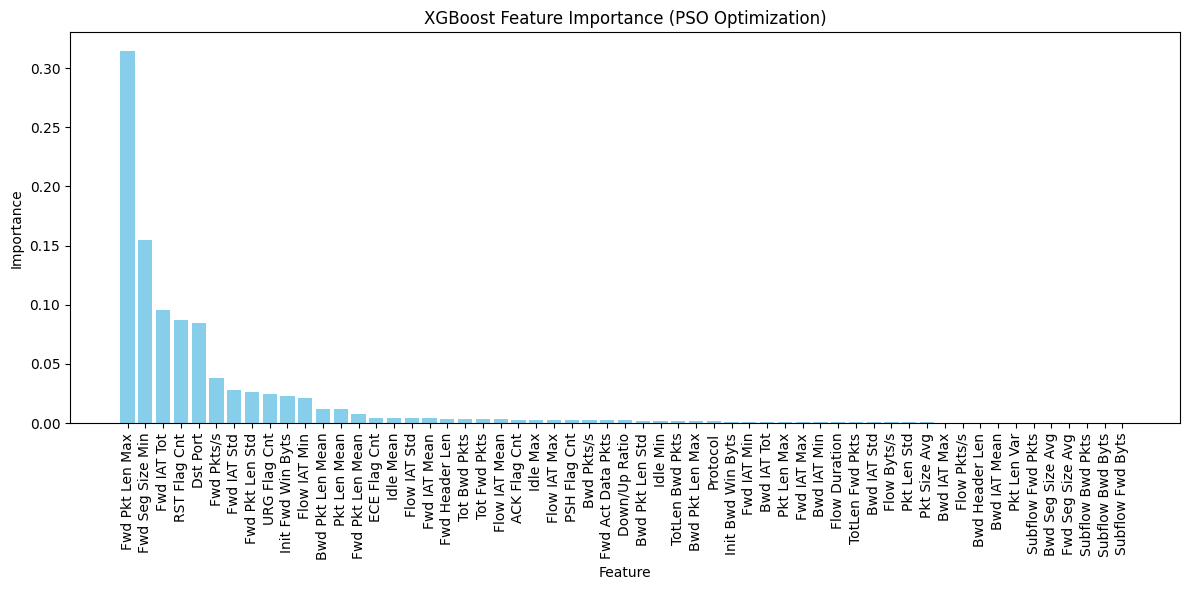


📊 Top 10 Feature Importances:
 1. Fwd Pkt Len Max - 0.3144
 2. Fwd Seg Size Min - 0.1544
 3. Fwd IAT Tot - 0.0954
 4. RST Flag Cnt - 0.0869
 5. Dst Port - 0.0849
 6. Fwd Pkts/s - 0.0384
 7. Fwd IAT Std - 0.0281
 8. Fwd Pkt Len Std - 0.0265
 9. URG Flag Cnt - 0.0248
 10. Init Fwd Win Byts - 0.0226


In [9]:
# ========================================
# FEATURE IMPORTANCE ANALYSIS (PSO)
# ========================================

if 'XGBoost' in trained_models:
    model = trained_models['XGBoost']
    feature_importances = model.feature_importances_
    
    # Trier les features par importance
    sorted_idx = np.argsort(feature_importances)[::-1]
    sorted_importances = feature_importances[sorted_idx]
    feature_names = X_full.columns[sorted_idx]
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(sorted_importances)), sorted_importances, color='skyblue')
    plt.xticks(range(len(sorted_importances)), feature_names, rotation=90)
    plt.title("XGBoost Feature Importance (PSO Optimization)")
    plt.ylabel("Importance")
    plt.xlabel("Feature")
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_MODEL_DIR, 'feature_importance_pso.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Top 10 Feature Importances:")
    for i in range(10):
        print(f" {i+1}. {feature_names[i]} - {sorted_importances[i]:.4f}")
